# Homework 5: Precipitation Nowcasting using Neural Networks

In this exercise, you are going to build a set of deep learning models on a real world task using PyTorch. PyTorch is an open source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab (FAIR).

## Setting up to use the gpu  

Before we start, we need to change the environment of Colab to use GPU. Do so by:

Runtime -> Change runtime type -> Hardware accelerator -> GPU

## Deep Neural Networks with PyTorch ##

To complete this exercise, you will need to build deep learning models for precipitation nowcasting. You will build a subset of the models shown below:
- Fully Connected (Feedforward) Neural Network
- Two-Dimentional Convolution Neural Network (2D-CNN)
- Recurrent Neural Network with Gated Recurrent Unit (GRU)

and one more model of your choice to achieve the highest score possible.

We provide the code for data cleaning and some starter code for PyTorch in this notebook but feel free to modify those parts to suit your needs. Feel free to use additional libraries (e.g. scikit-learn) as long as you have a model for each type mentioned above.

This notebook assumes you have already installed PyTorch with python3 and had GPU enabled. If you run this exercise on Colab you are all set.

## Precipitation Nowcasting ##

Precipitation nowcasting is the the task of predicting the amount of rainfall in a certain region given some kind of sensor data.  The term nowcasting refers to tasks that try to predict the current or near future conditions (within 6 hours).

You will be given satellite images in 3 different bands covering a 5 by 5 region from different parts of Thailand. In other words, your input will be a 5x5x3 image. Your task is to predict the amount of rainfall in the center pixel. You will first do the prediction using just a simple fully-connected neural network that view each pixel as different input features.

Since the your input is basically an image, we will then view the input as an image and apply CNN to do the prediction. Finally, we can also add a time component since weather prediction can benefit greatly using previous time frames. Each data point actually contain 5 time steps, so each input data point has a size of 5x5x5x3 (time x height x width x channel), and the output data has a size of 5 (time). You will use this time information when you work with RNNs.

Finally, we would like to thank the Thai Meteorological Department for providing the data for this assignment.

In [ ]:
!nvidia-smi

In [ ]:
# For summarizing and visualizing models
!pip install torchinfo
!pip install torchviz

## Weights and Biases

[Weights and Biases](https://docs.wandb.ai/company) (wandb) is an experiment tracking tool for machine learning. It can log and visualize experiments in real time. It supports many popular ML frameworks, and obviously PyTorch is one of them. In this notebook you will learn how to log general metrics like losses, parameter distributions, and gradient distribution with wandb.

To install wandb, run the cell below

In [ ]:
!pip install wandb

# Dependencies

In [ ]:
import os
import math
import copy
import tarfile
import pickle
import urllib
import wandb
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from sklearn import preprocessing
from torchviz import make_dot
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torchinfo import summary
from tqdm.notebook import tqdm
from huggingface_hub import hf_hub_download
from kaggle_secrets import UserSecretsClient

torch.__version__

## Setup

1. Register [Wandb account](https://wandb.ai/login?signup=true) (and confirm your email)

2. `wandb login` and copy paste the API key when prompt

In [ ]:
WANDB_API_KEY = UserSecretsClient().get_secret("WANDB_API_KEY")
wandb.login(key=WANDB_API_KEY)

## Loading the data

The data is on huggingface, a website that allows people to share datasets and pretrained models.

In [ ]:
hf_hub_download(
    repo_id="ecitslos/HWnowcastingdata",
    filename="nowcastingHWdataset.tar.gz",
    repo_type="dataset",
    local_dir=".",
)

In [ ]:
DATASET_FILE_PATH = "/kaggle/working/nowcastingHWdataset.tar.gz"

with tarfile.open(DATASET_FILE_PATH, "r:gz") as tar:
    tar.extractall(path=".")

# Data Explanation #

The data is an hourly measurement of water vapor in the atmosphere, and two infrared measurements of cloud imagery on a latitude-longitude coordinate. Each measurement is illustrated below as an image. These three features are included as different channels in your input data.

<img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/wvapor.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud1.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud2.png" width="200">

We also provide the hourly precipitation (rainfall) records in the month of June, July, August, September, and October from weather stations spreaded around the country. A 5x5 grid around each weather station at a particular time will be paired with the precipitation recorded at the corresponding station as input and output data. Finally, five adjacent timesteps are stacked into one sequence.

The month of June-August are provided as training data, while the months of September and October are used as validation and test sets, respectively.


# Reading data

In [ ]:
def read_data(months, data_dir="/kaggle/working/dataset"):
    features = np.array([], dtype=np.float32).reshape(0, 5, 5, 5, 3)
    labels = np.array([], dtype=np.float32).reshape(0, 5)
    for m in months:
        filename = "features-m{}.pk".format(m)
        with open(os.path.join(data_dir, filename), "rb") as file:
            features_temp = pickle.load(file)
        features = np.concatenate((features, features_temp), axis=0)

        filename = "labels-m{}.pk".format(m)
        with open(os.path.join(data_dir, filename), "rb") as file:
            labels_temp = pickle.load(file)
        labels = np.concatenate((labels, labels_temp), axis=0)

    return features, labels

In [ ]:
# use data from month 6,7,8 as training set
x_train, y_train = read_data(months=[6, 7, 8])

# use data from month 9 as validation set
x_val, y_val = read_data(months=[9])

# use data from month 10 as test set
x_test, y_test = read_data(months=[10])

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape, "\n")
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape, "\n")
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

**features**
- dim 0: number of entries
- dim 1: number of time-steps in ascending order
- dim 2,3: a 5x5 grid around rain-measued station
- dim 4: water vapor and two cloud imagenaries

**labels**
- dim 0: number of entries
- dim 1: number of precipitation for each time-step

# Three-Layer Feedforward Neural Networks

In [ ]:
# Dataset need to be reshaped to make it suitable for feedforword model
def preprocess_for_ff(x_train, y_train, x_val, y_val):
    x_train_ff = x_train.reshape((-1, 5 * 5 * 3))
    y_train_ff = y_train.reshape((-1, 1))
    x_val_ff = x_val.reshape((-1, 5 * 5 * 3))
    y_val_ff = y_val.reshape((-1, 1))
    x_test_ff = x_test.reshape((-1, 5 * 5 * 3))
    y_test_ff = y_test.reshape((-1, 1))

    return x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff


x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff = preprocess_for_ff(
    x_train, y_train, x_val, y_val
)
print(x_train_ff.shape, y_train_ff.shape)
print(x_val_ff.shape, y_val_ff.shape)
print(x_test_ff.shape, y_test_ff.shape)

### T1

Explain each line of code in the function preprocess_for_ff()

**Ans:**

## Dataset

To prepare a DataLoader in order to feed data into the model, we need to create a `torch.utils.data.Dataset` object first. (Learn more about it [here](https://pytorch.org/docs/stable/data.html#map-style-datasets))

Dataset is a simple class that the DataLoader will get data from, most of its functionality comes from `__getitem__(self, index)` method, which will return a single data point (both input and label). In real world scenarios the method can do some other stuffs such as

1. Load images

If your input (x) are images. Oftentimes you won't be able to fit all the training images into your RAM. Thus, you should pass an array (or list) of image path into the dataloader, and the `__getitem__` will be the one who dynamically loads the actual image from the harddisk for you.

2. Data Normalization

Data normalization helps improve stability of training. Unnormalized data can cause gradients to explode. There are many variants of normalization, but in this notebook we will use either minmax or z-score (std) normalization. Read [this](https://developers.google.com/machine-learning/data-prep/transform/normalization) (or google) if you wish to learn more about data normalization.

3. Data Augmentation

In computer vision, you might want to apply small changes to the images you use in training (adjust brightness, contrast, rotation) so that the model will generalize better on unseen data. There are two kinds of augmentation: static and dynamic. Static augmentation will augment images and save to disk as a new dataset. On the other hand, rather than applying the change initially and use the same change on each image every epoch, dynamic augmentation will augment each data differently for each epoch. Note that augmentation is usually done on the CPU and you might be bounded by the CPU instead. PyTorch has a dedicated [documentation about data augmentation](https://pytorch.org/vision/master/transforms.html) if you want to know more.

In [ ]:
class RainfallDatasetFF(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)
        self.normalizer = normalizer
        print(self.x.shape)
        print(self.y.shape)

    def __getitem__(self, index):
        x = self.x[index]  # Retrieve data
        x = self.normalizer.transform(x.reshape(1, -1))  # Normalize
        y = self.y[index]
        return x, y

    def __len__(self):
        return self.x.shape[0]

In [ ]:
def normalizer_std(X):
    scaler = preprocessing.StandardScaler().fit(X)
    return scaler


def normalizer_minmax(X):
    scaler = preprocessing.MinMaxScaler().fit(X)
    return scaler

In [ ]:
normalizer = normalizer_std(x_train_ff)  # We will normalize everything based on x_train

train_dataset = RainfallDatasetFF(x_train_ff, y_train_ff, normalizer)
val_dataset = RainfallDatasetFF(x_val_ff, y_val_ff, normalizer)
test_dataset = RainfallDatasetFF(x_test_ff, y_test_ff, normalizer)

## DataLoader

DataLoader feeds data from our dataset into the model. We can freely customize batch size, data shuffle for each data split, and much more with DataLoader class. If you're curious about what can you do with PyTorch's DataLoader, you can check [this documentation](https://pytorch.org/docs/stable/data.html)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, pin_memory=True)

## Loss Function

PyTorch has many loss functions readily available for use. We can also write our own custom loss function as well. But for now, we will use [PyTorch's built-in mean squared error loss ](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

In [ ]:
loss_fn = nn.MSELoss()

### T2

Why is the loss MSE?

**Ans:**

## Device

Unlike Tensorflow/Keras, PyTorch allows user to freely put any Tensor or objects (loss functions, models, optimizers, etc.) in CPU or GPU. By default, all objects created will be in CPU. In order to use GPU we will have to supply `device = torch.device("cuda")` into the objects to move it to GPU. You will usually see the syntax like `object.to(device)` for moving CPU object to GPU, or `o = Object(..., device=device)` to create the object in the GPU.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model

Below, the code for creating a 3-layers fully connected neural network in PyTorch is provided. Run the code and make sure you understand what you are doing. Then, report the results.

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, hidden_size=200):
        super(FeedForwardNN, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1 = F.relu(self.ff1(x))
        hd2 = F.relu(self.ff2(hd1))
        y = F.relu(self.ff3(hd2))
        y = self.out(y)
        return y.reshape(-1, 1)

### T3

What is the activation function in the final dense layer? and why? Do you think there is a better activation function for the final layer?

**Ans:**

In [ ]:
# Hyperparameters and other configs
config = {
    "architecture": "feedforward",
    "lr": 0.01,
    "hidden_size": 200,
    "scheduler_factor": 0.2,
    "scheduler_patience": 2,
    "scheduler_min_lr": 1e-4,
    "epochs": 10,
}

# Model
model_ff = FeedForwardNN(hidden_size=config["hidden_size"])
model_ff = model_ff.to(device)
optimizer = torch.optim.Adam(model_ff.parameters(), lr=config["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    "min",
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
    min_lr=config["scheduler_min_lr"],
)

In [ ]:
# Visualize model with torchviz
sample_inputs = next(iter(train_loader))[0].requires_grad_(True)
sample_y = model_ff(sample_inputs.to(device))
make_dot(
    sample_y,
    params=dict(list(model_ff.named_parameters()) + [("sample_inputs", sample_inputs)]),
)

In [ ]:
summary(model_ff, input_size=(1024, 75))

### T4

Explain why the first linear layer has number of parameters = 15200

**Ans:**

# Training

In [ ]:
train_losses = []
val_losses = []
learning_rates = []

# Start wandb run
wandb.init(
    project="precipitation-nowcasting-2026",
    config=config,
)

# Log parameters and gradients
# This makes the training slow. Do this when you are debugging only.
# You should avoid doing this when doing serious training.
wandb.watch(model_ff, log="all")

for epoch in range(config["epochs"]):  # loop over the dataset multiple times

    # Training
    train_loss = []
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # Flag model as training. Some layers behave differently in training and
    # inference modes, such as dropout, BN, etc.
    model_ff.train()

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer.zero_grad()

        # Predict
        y_pred = model_ff(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer.step()

        # Log stuff
        train_loss.append(loss)

    avg_train_loss = torch.stack(train_loss).mean().item()
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # Validation
    model_ff.eval()
    with torch.no_grad():  # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        val_loss = []
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log stuff
            val_loss.append(loss)

        avg_val_loss = torch.stack(val_loss).mean().item()
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

        # LR adjustment with scheduler
        scheduler.step(avg_val_loss)

        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            # Save whatever you want
            state = {
                "epoch": epoch,
                "model": model_ff.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "best_val_loss": best_val_loss,
            }

            print(f"Saving new best model..")
            torch.save(state, "model_ff.pth.tar")

    wandb.log(
        {
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr": current_lr,
        }
    )

wandb.finish()
print("Finished Training")

You might want to download the saved model (model_ff.pth.tar) for later uses if you are running on Colab.

### T5

Plot loss and val_loss as a function of epochs.

In [ ]:
# Generate a sequence of epoch numbers for the x-axis
epochs = range(1, len(train_losses) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, "b-", label="Training Loss (MSE)")
plt.plot(epochs, val_losses, "r-", label="Validation Loss (MSE)")

# Add labels, title, and legend
plt.title("Training and Validation Losses over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

### T6

When does the model start to overfit?

**Ans:**

### T7

Plot the learning rate as a function of the epochs.

In [ ]:
# Generate a sequence of epoch numbers for the x-axis
epochs = range(1, len(learning_rates) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(
    epochs, learning_rates, "g-o", label="Learning Rate", linewidth=2, markersize=6
)

# Add labels, title, and legend
plt.title("Learning Rate over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

### T8

What makes the learning rate change?
(hint: try to understand the scheduler [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html))


**Ans:**

# Load Model

Use the code snippet below to load the model you just trained

In [ ]:
MODEL_CHECKPOINT_PATH = "/kaggle/working/model_ff.pth.tar"

checkpoint = torch.load(MODEL_CHECKPOINT_PATH)
loaded_model = FeedForwardNN(hidden_size=config["hidden_size"])  # Create model object
loaded_model.load_state_dict(checkpoint["model"])  # Load weights
print(f"Loaded epoch {checkpoint['epoch']} model")

# A more complex scheduling

The scheduler can be very complicated and you can write your own heuristic for it.

### T9

Implement a custom learning rate scheduler that behaves like the following graph.

You might want to learn how to use [PyTorch's built-in learning rate schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) in order to build your own.

Learning rate should be function of epoch.

![](https://raw.githubusercontent.com/pjumruspun/ComProg2021-Workshop/main/graph.png)

In [ ]:
class MyScheduler:
    def __init__(self, optimizer: torch.optim.Optimizer):
        self.optimizer = optimizer
        self.base_lrs = [group["lr"] for group in optimizer.param_groups]

    def step(self, epoch):
        scale_factor = 0.8**epoch

        # Apply the new learning rate to the optimizer
        for i, group in enumerate(self.optimizer.param_groups):
            new_lr = self.base_lrs[i] * scale_factor
            group["lr"] = new_lr

In [ ]:
# Initialize model and optimizer
model_ff = FeedForwardNN(hidden_size=config["hidden_size"]).to(device)
optimizer = torch.optim.Adam(model_ff.parameters(), lr=config["lr"])

# Initialize scheduler
my_scheduler = MyScheduler(optimizer)

# Track performance
train_losses = []
val_losses = []
learning_rates = []

In [ ]:
for epoch in range(config["epochs"]):
    # Training
    train_loss = []
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # Flag model as training.
    model_ff.train()

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer.zero_grad()

        # Predict
        y_pred = model_ff(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer.step()

        # Log stuff
        train_loss.append(loss)

    avg_train_loss = torch.stack(train_loss).mean().item()
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # Validation
    model_ff.eval()
    with torch.no_grad():  # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        val_loss = []
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log stuff
            val_loss.append(loss)

        avg_val_loss = torch.stack(val_loss).mean().item()
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

    # Update the learning rate at the end of the epoch
    my_scheduler.step(epoch + 1)

# [Optional] Wandb #

You should now have a project in wandb with the name `precipitation-nowcasting`, which you should see the latest run you just finished inside the project. If you look into the run, you should be able to see plots of learning rate, train loss, val loss in the `Charts` section. Below it should be `Gradients` and `Parameters` section.

# Wandb Observation #

### OT1

Write your own interpretation of the logs from this example. A simple sentence or two for each section is sufficient.

**Your answer:**

# Evaluation

In [ ]:
################################################################################
# T10:                                                                     #
# Write a function to evaluate your model. Your function must predicts         #
# using the input model and return mean square error of the model.             #
#                                                                              #
# Hint: Read how to use PyTorch's MSE Loss                                     #
# https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


def evaluate(data_loader, model):
    """
    Evaluate model on validation data given by data_loader
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize MSE loss function
    loss_fn = nn.MSELoss()

    # Safely get the device the model is currently on
    device = next(model.parameters()).device

    batch_losses = []

    # Disable gradient calculation to save memory and speed up inference
    with torch.no_grad():
        for inputs, y_true in data_loader:
            # Transfer data to the correct device (GPU/CPU)
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Forward pass: make predictions
            y_pred = model(inputs)

            # Calculate MSE loss for this batch
            loss = loss_fn(y_pred, y_true)
            batch_losses.append(loss)

    # Calculate the mean of all batch losses and convert to a standard Python float
    mse = torch.stack(batch_losses).mean().item()

    return mse

In [ ]:
# We will use majority rule as a baseline.
def majority_baseline(label_set):
    unique, counts = np.unique(label_set, return_counts=True)
    majority = unique[np.argmax(counts)]
    baseline = 0
    label_set = label_set.reshape(-1, 1)
    for r in label_set:
        baseline += (majority - r) ** 2 / len(label_set)
    return baseline

In [ ]:
print("baseline")
print("train", majority_baseline(y_train))
print("validate", majority_baseline(y_val))

In [ ]:
print("FF-model")
print("train", evaluate(train_loader, model_ff))
print("validate", evaluate(val_loader, model_ff))

# Dropout #

You might notice that the 3-layered feedforward does not use dropout at all. Now, try adding dropout (dropout rate of 20%) to the model, run, and report the result again.

To access PyTorch's dropout, use `nn.Dropout`. Read more about PyTorch's built-in Dropout layer [here](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [ ]:
################################################################################
# T11:                                                                     #
# Write a feedforward model with dropout                                       #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class FeedForwardNNDropout(nn.Module):
    def __init__(self, hidden_size=200, dropout_rate=0.5):
        super(FeedForwardNNDropout, self).__init__()
        # Linear layers
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

        # Dropout layer
        # p is the probability of an element to be zeroed out
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        # Apply dropout after the ReLU activation for each hidden layer
        hd1 = self.dropout(F.relu(self.ff1(x)))
        hd2 = self.dropout(F.relu(self.ff2(hd1)))
        y = self.dropout(F.relu(self.ff3(hd2)))

        # Output layer (no dropout applied here)
        y = self.out(y)
        return y.reshape(-1, 1)

In [ ]:
################################################################################
# T12:                                                                     #
# Complete the code to train your dropout model                                #
################################################################################
print("start training ff dropout")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

# Initialize the new dropout model
model_ff_dropout = FeedForwardNNDropout(
    hidden_size=config["hidden_size"], dropout_rate=0.5
)
model_ff_dropout = model_ff_dropout.to(device)

# Initialize the optimizer and scheduler
optimizer = torch.optim.Adam(model_ff_dropout.parameters(), lr=config["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    "min",
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
    min_lr=config["scheduler_min_lr"],
)

# Lists to keep track of losses
train_losses_dropout = []
val_losses_dropout = []

In [ ]:
for epoch in range(config["epochs"]):

    # TRAINING
    model_ff_dropout.train()
    train_loss = []

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"\nTraining epoch {epoch+1} (LR: {current_lr})...")

    for inputs, y_true in tqdm(train_loader):
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()
        y_pred = model_ff_dropout(inputs)
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()

        train_loss.append(loss.detach())

    avg_train_loss = torch.stack(train_loss).mean().item()
    train_losses_dropout.append(avg_train_loss)

    # VALIDATION
    model_ff_dropout.eval()
    val_loss = []

    with torch.no_grad():
        for inputs, y_true in tqdm(val_loader):
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            y_pred = model_ff_dropout(inputs)
            loss = loss_fn(y_pred, y_true)
            val_loss.append(loss.detach())

    avg_val_loss = torch.stack(val_loss).mean().item()
    val_losses_dropout.append(avg_val_loss)

    print(
        f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

    # Step the scheduler based on the validation loss
    scheduler.step(avg_val_loss)

### T13

Plot the losses and MSE of the training and validation as before. Evaluate the dropout model's performance

In [ ]:
# Plot here
# Generate the x-axis values based on the number of epochs recorded
epochs_dropout = range(1, len(train_losses_dropout) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_dropout, train_losses_dropout, "b-", label="Training Loss (Dropout)")
plt.plot(epochs_dropout, val_losses_dropout, "r-", label="Validation Loss (Dropout)")

# Add labels, title, and legend
plt.title("Training vs Validation Loss with Dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
# Evaluate
dropout_mse = evaluate(val_loader, model_ff_dropout)

print(f"Dropout Model Validation MSE: {dropout_mse:.4f}")

# Convolution Neural Networks
Now let's try to incorporate the grid sturcture to your model. Instead of passing in vectors, we are going to pass in the 5x5 grid into the model (5lat x 5long x 3channel). You are going to implement you own 2d-convolution neural networks with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
Conv2DNN                                 --                        --
├─Conv2d: 1-1                            [1024, 200, 3, 3]         5,600
├─Linear: 1-2                            [1024, 200]               360,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
==========================================================================================
Total params: 406,201
Trainable params: 406,201
Non-trainable params: 0
```
These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         

Hint: You should read PyTorch documentation to see the list of available layers and options you can use.                         

In [ ]:
################################################################################
# T14:                                                                     #
# Complete the code for preparing data for training CNN                        #
# Input for CNN should not have time step.                                     #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


def get_tensor_x_data_cnn(x_data):
    x_data_cnn = x_data[:, -1, :, :, :]
    tensor_x_data_cnn = torch.tensor(x_data_cnn, dtype=torch.float32)
    tensor_x_data_cnn = tensor_x_data_cnn.permute(0, 3, 1, 2)

    return tensor_x_data_cnn


def get_tensor_y_data_cnn(y_data):
    tensor_y_data_cnn = torch.tensor(y_data, dtype=torch.float32)
    if len(tensor_y_data_cnn.shape) > 1 and tensor_y_data_cnn.shape[1] > 1:
        tensor_y_data_cnn = tensor_y_data_cnn[:, -1].unsqueeze(1)

    return tensor_y_data_cnn

In [ ]:
# Arrange data
tensor_x_train_cnn = get_tensor_x_data_cnn(x_train)
tensor_y_train = get_tensor_y_data_cnn(y_train)

tensor_x_val_cnn = get_tensor_x_data_cnn(x_val)
tensor_y_val = get_tensor_y_data_cnn(y_val)

tensor_x_test_cnn = get_tensor_x_data_cnn(x_test)
tensor_y_test = get_tensor_y_data_cnn(y_test)

# Create PyTorch Datasets
train_dataset_cnn = TensorDataset(tensor_x_train_cnn, tensor_y_train)
val_dataset_cnn = TensorDataset(tensor_x_val_cnn, tensor_y_val)
test_dataset_cnn = TensorDataset(tensor_x_test_cnn, tensor_y_test)

# Create PyTorch DataLoaders
batch_size = 64

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=batch_size, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size, shuffle=False)

In [ ]:
################################################################################
# T15:                                                                         #
# Write a PyTorch convolutional neural network model.                          #
# You might want to use the layer torch.flatten somewhere                      #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(
            in_channels=16, out_channels=32, kernel_size=3, padding=1
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 1 * 1, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # Convolutional layers with ReLU and Pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the feature maps into a 1D vector
        x = torch.flatten(x, 1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
################################################################################
# T16:                                                                         #
# Complete the code to train your cnn model                                    #
################################################################################
print("start training conv2d")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

# Initialize the model
model_cnn = CNNModel()
model_cnn.to(device)

# Define Loss function and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

# Training Loop
num_epochs = 10

# Storing losses
train_losses = []
val_losses = []

In [ ]:
for epoch in range(num_epochs):
    model_cnn.train()  # Set model to training mode
    running_loss = 0.0

    # Store losses for the current batch
    batch_train_losses = []

    for i, data in enumerate(train_loader_cnn, 0):
        inputs, labels = data

        # Move data to GPU if available
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_cnn(inputs)

        # Extract only the target for the last timestep
        if len(labels.shape) > 1 and labels.shape[1] > 1:
            labels = labels[:, -1].unsqueeze(1)

        # Ensure labels have the same shape as outputs for MSELoss
        labels = labels.view_as(outputs)

        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    # Average loss for the epoch
    epoch_train_loss = sum(batch_train_losses) / len(batch_train_losses)
    train_losses.append(epoch_train_loss)

    # Evaluate on validation set after each epoch
    epoch_val_loss = evaluate(val_loader_cnn, model_cnn)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} - Train MSE: {epoch_train_loss:.4f}, Val MSE: {epoch_val_loss:.4f}"
    )

In [ ]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("CNN Model Loss (MSE) Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate
train_mse = evaluate(train_loader_cnn, model_cnn)
val_mse = evaluate(val_loader_cnn, model_cnn)

print(f"Final Training MSE: {train_mse:.4f}")
print(f"Final Validation MSE: {val_mse:.4f}")

# [Optional] Gated Recurrent Units

Now, you want to add time steps into your model. Recall the original data has 5 time steps per item. You are going to pass in a data of the form 5 timesteps x 75data. This can be done using a GRU layer. Implement you own GRU network with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
GRUModel                                 --                        --
├─GRU: 1-1                               [1024, 5, 200]            166,200
├─Linear: 1-2                            [1024, 5, 200]            40,200
├─Linear: 1-3                            [1024, 5, 1]              201
==========================================================================================
Total params: 206,601
Trainable params: 206,601
Non-trainable params: 0
```


These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         
The result should be better than the feedforward model and at least on par with your CNN model.    

Do consult PyTorch documentation on how to use [GRUs](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html).


In [ ]:
################################################################################
# OT2:                                                                     #
# Complete the code for preparing data for training GRU                        #
# GRU's input should has 3 dimensions.                                         #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

In [ ]:
################################################################################
# OT3:                                                                      #
# Write a PyTorch GRU model.                                                   #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

In [ ]:
################################################################################
# OT4:                                                                      #
# Complete the code to train your gru model                                    #
################################################################################
print("start training gru")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

In [ ]:
# Plot

In [ ]:
# Evaluate

# Transformer

Welcome to the beginning of the real world! The aboved models are not usually used in practice due to its limited capability. Transformers are generally used by computer vision, natural language processing, and speech processing (almost every big AI fields).



In our dataloader, we will add the output of this timestep (the number of precipitation) as an auxiliary input to predict the next timestep. Thus, input for the model should be [#batch_size, 5, 76] (5 timesteps and the number 76 comes from (3x5x5)+1) and the output for the model should be [#batch_size, 1] which would be the next timestep we want to predict. Additionally, we will mask the input at the dataloader to the attenttion from observing future values. Suppose that we want to predict timestep 3, we will mask the timestep 3, 4 and 5 in our input by setting it to zeros, and we will predict the timestep 3.

In order to get a score on this TODO, students need to implement a dataloader that mask the input correctly.

(Note, in this homework, we ask you to mask the input which is simple to do. In practice, people prefer to mask the attention mask instead. This makes decoder-only architectures more parallelizable.)

In [ ]:
################################################################################
# T17:                                                                        #
# Complete the code for preparing data for training Transformer                #
# Transformer's input should has 3 dimensions.                                 #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class TransformerDataset(Dataset):
    def __init__(self, X, y):
        # Convert to PyTorch tensors
        self.X = (
            torch.tensor(X, dtype=torch.float32)
            if not isinstance(X, torch.Tensor)
            else X.clone().detach()
        )
        self.y = (
            torch.tensor(y, dtype=torch.float32)
            if not isinstance(y, torch.Tensor)
            else y.clone().detach()
        )

        self.num_samples = self.X.shape[0]
        self.seq_len = self.X.shape[1]

    def __len__(self):
        return self.num_samples * self.seq_len

    def __getitem__(self, idx):
        # Determine which original sample and which timestep to predict
        sample_idx = idx // self.seq_len
        t = idx % self.seq_len

        # Extract the sequence and ensure targets are 1D
        X_seq = self.X[sample_idx].clone()  # Shape: (5, 75)
        y_seq = self.y[sample_idx].clone().view(-1)  # Shape: (5,)

        # Add the output of the previous timestep as an auxiliary input
        # Shift targets by 1
        y_shifted = torch.zeros(self.seq_len, 1)
        y_shifted[1:] = y_seq[:-1].unsqueeze(1)

        # Concatenate features and auxiliary input to get (5, 76)
        X_combined = torch.cat((X_seq, y_shifted), dim=1)

        # Mask current and future timesteps
        # Suppose we want to predict t = 2, we mask t = 2,3,4 to zeros.
        X_combined[t:, :] = 0.0

        # The target is the actual precipitation at timestep t
        target = y_seq[t].unsqueeze(0)  # Shape: (1,)

        return X_combined, target

In [ ]:
# Reshape the input data to 3 dimensions: (entries, time-step, features)
# Flattening the spatial and channel dimensions into a single feature dimension
x_train_trans = x_train.reshape(x_train.shape[0], x_train.shape[1], -1)
x_val_trans = x_val.reshape(x_val.shape[0], x_val.shape[1], -1)
x_test_trans = x_test.reshape(x_test.shape[0], x_test.shape[1], -1)

# Create the custom datasets using your exact 'y' variable names
train_dataset_trans = TransformerDataset(x_train_trans, y_train)
val_dataset_trans = TransformerDataset(x_val_trans, y_val)
test_dataset_trans = TransformerDataset(x_test_trans, y_test)

# Create DataLoaders
batch_size = 1024

train_loader_trans = DataLoader(
    train_dataset_trans, batch_size=batch_size, shuffle=True
)
val_loader_trans = DataLoader(val_dataset_trans, batch_size=batch_size, shuffle=False)
test_loader_trans = DataLoader(test_dataset_trans, batch_size=batch_size, shuffle=False)


In this task, we will implement one encoder layer of Transformer and add the linear layer to make a regression prediction. For the simplicity of the model, we will change the multi-head attention to QKV self-attention (single-head). As a result, our model should look like the diagram below. Since the layer self-attention is not availble in torch, students have to implement it themselves. In Add & Norm layer, students have to do the addition before normalizing. In Layer Normalization, we will normalize across both timesteps and features.

If you feel loss in this part of the assignment, watching this [video](https://www.youtube.com/watch?v=kCc8FmEb1nY) might help.

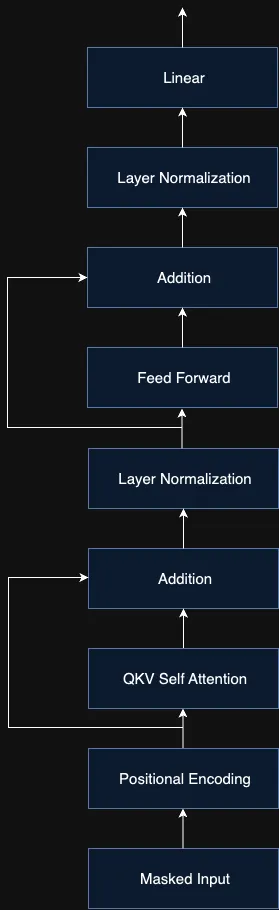

```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
TransformerModel                         [1024, 1]                 --
├─PositionalEncoding: 1-1                [1024, 5, 76]             --
│    └─Dropout: 2-1                      [1024, 5, 76]             --
├─SelfAttention: 1-2                     [1024, 5, 76]             --
│    └─Linear: 2-2                       [1024, 5, 76]             5,852
│    └─Linear: 2-3                       [1024, 5, 76]             5,852
│    └─Linear: 2-4                       [1024, 5, 76]             5,852
│    └─Softmax: 2-5                      [1024, 5, 5]              --
├─LayerNorm: 1-3                         [1024, 5, 76]             760
├─Linear: 1-4                            [1024, 5, 76]             5,852
├─LayerNorm: 1-5                         [1024, 5, 76]             760
├─Linear: 1-6                            [1024, 1]                 381
==========================================================================================
Total params: 25,309
Trainable params: 25,309
Non-trainable params: 0
Total mult-adds (M): 25.92
==========================================================================================
Input size (MB): 1.56
Forward/backward pass size (MB): 18.69
Params size (MB): 0.10
Estimated Total Size (MB): 20.34
==========================================================================================
```

In [ ]:
################################################################################
# T18                                                                         #
# Write a PyTorch PositionalEncoding Layer.                                    #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class PositionalEncoding(nn.Module):
    def __init__(self, seq_len, emb_dim, dropout=0.2):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a matrix of shape (seq_len, emb_dim) to hold positional encodings
        pe = torch.zeros(seq_len, emb_dim)

        # Create a vector of positions (0, 1, 2, ..., seq_len-1)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)

        # Calculate the division term for the sine and cosine arguments
        div_term = torch.exp(
            torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
        )

        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add a batch dimension: (1, seq_len, emb_dim)
        pe = pe.unsqueeze(0)

        # Register pe as a buffer (it's not a trainable parameter, but stays with the model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len, emb_dim)
        """
        # Add the positional encoding to the input embedding
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

In [ ]:
################################################################################
# T19                                                                         #
# Write a PyTorch Transformer model.                                           #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class SelfAttention(nn.Module):
    def __init__(self, input_dim):
        super(SelfAttention, self).__init__()
        # Query, Key, and Value linear transformations
        self.q = nn.Linear(input_dim, input_dim)
        self.k = nn.Linear(input_dim, input_dim)
        self.v = nn.Linear(input_dim, input_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        # Attention scores
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(x.size(-1))
        attention_weights = self.softmax(attention_scores)

        # Weighted sum
        out = torch.matmul(attention_weights, V)
        return out

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, seq_len=5, input_dim=76):
        super(TransformerModel, self).__init__()

        # Positional Encoding
        self.pos_encoder = PositionalEncoding(seq_len, input_dim)

        # Self Attention
        self.attention = SelfAttention(input_dim)

        # LayerNorm 1: Normalizing over (seq_len, input_dim) -> 760 params
        self.norm1 = nn.LayerNorm((seq_len, input_dim))

        # Feed-Forward Linear layer -> 5852 params
        self.linear_ffn = nn.Linear(input_dim, input_dim)

        # LayerNorm 2: -> 760 params
        self.norm2 = nn.LayerNorm((seq_len, input_dim))

        # Final Output layer -> 381 params
        # It takes the flattened output (5 * 76 = 380) and predicts 1 value
        self.fc_out = nn.Linear(seq_len * input_dim, 1)

    def forward(self, x):
        # Apply positional encoding
        x = self.pos_encoder(x)

        # Self-Attention with a residual connection
        attn_out = self.attention(x)
        x = self.norm1(x + attn_out)

        # Feed-Forward layer with a residual connection
        ffn_out = self.linear_ffn(x)
        x = self.norm2(x + ffn_out)

        # Flatten the sequence and feature dimensions: (batch_size, 5 * 76)
        x = torch.flatten(x, start_dim=1)

        # Final prediction: (batch_size, 1)
        out = self.fc_out(x)
        return out

In [ ]:
################################################################################
# T20                                                                         #
# Complete the code to train your Transformer model                           #
################################################################################
print("start training transformer")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

# Initialize model
model_transformer = TransformerModel(seq_len=5, input_dim=76)
model_transformer = model_transformer.to(device)

# Loss function
criterion = nn.MSELoss()

# Transformers optimizaer
optimizer = optim.Adam(model_transformer.parameters(), lr=0.0001)

# Number of epochs
num_epochs = 10

# Storing losses
train_losses = []
val_losses = []

In [ ]:
for epoch in range(num_epochs):
    model_transformer.train()
    epoch_train_loss = 0.0
    num_batches = 0

    for inputs, targets in train_loader_trans:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model_transformer(inputs)

        # Ensure target shape matches output shape
        targets = targets.view_as(outputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    # Calculate average training loss for the epoch
    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)

    # Evaluate on the validation set at the end of the epoch
    avg_val_loss = evaluate(val_loader_trans, model_transformer)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}"
    )

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.title("Transformer Model Training and Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

If you implement it correctly, you should evaluate the model in the test dataset and the score should be better than the aboved models.

In [ ]:
# Evaluate
final_train_mse = evaluate(train_loader_trans, model_transformer)
final_val_mse = evaluate(val_loader_trans, model_transformer)

print(f"Final Training MSE: {final_train_mse:.4f}")
print(f"Final Validation MSE: {final_val_mse:.4f}")

# Final Section
# PyTorch playground

Now, train the best model you can do for this task. You can use any model structure and function available.    
Remember that trainig time increases with the complexity of the model. You might find printing computation graphs helpful in debugging complicated models.    
Your model should be better than your CNN or Transformer model in the previous sections.

Some ideas:

- Tune the hyperparameters
- Adding dropouts
- Combining different types of models

You should tune your model on training and validation set.    
**The test set should be used only for the last evaluation.**

In [ ]:
# Prep data as you see fit
train_loader_best = train_loader_trans
val_loader_best = val_loader_trans

In [ ]:
################################################################################
# T21                                                                     #
# Write a function that returns your best PyTorch model. You can use anything  #
# you want. The goal here is to create the best model you can think of.        #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


class BiLSTM_NowcastingModel(nn.Module):
    def __init__(self, input_dim=76, hidden_dim=128, num_layers=2, dropout=0.3):
        super(BiLSTM_NowcastingModel, self).__init__()

        # Bidirectional LSTM to capture temporal dependencies from past to future and vice versa
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # Fully connected layers for the final prediction
        # hidden_dim * 2 because it's bidirectional
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.layer_norm = nn.LayerNorm(64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Output layer predicting the 1 value (precipitation)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]

        # lstm_out shape: [batch_size, seq_len, hidden_dim * 2]
        lstm_out, (hidden_state, cell_state) = self.lstm(x)

        # Extract the output from the last timestep to predict the next timestep
        last_timestep_out = lstm_out[:, -1, :]

        # Pass through dense layers
        x = self.fc1(last_timestep_out)
        x = self.layer_norm(x)
        x = self.relu(x)
        x = self.dropout(x)

        out = self.fc2(x)
        return out


def get_best_model():
    """
    Returns an instance of the best model.
    Make sure the input_dim matches your dataloader (e.g., 76 based on previous steps).
    """
    # Initialize with the dimensions derived from your previous dataloaders
    model = BiLSTM_NowcastingModel(input_dim=76, hidden_dim=128, num_layers=2)
    return model

In [ ]:
################################################################################
# T22                                                                          #
# Complete the code to train your best model                                   #
################################################################################
print("start training the best model")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

# Initialize model
best_model = get_best_model()
best_model = get_best_model().to(device)

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(best_model.parameters(), lr=0.001)

# Epoch amount
num_epochs = 15

# Storing losses
best_train_losses = []
best_val_losses = []

# Storing best model weights
best_val_mse = float("inf")
best_model_weights = copy.deepcopy(best_model.state_dict())

In [ ]:
# Training Loop
for epoch in range(num_epochs):
    best_model.train()  # Set to training mode
    epoch_train_loss = 0.0

    for inputs, targets in train_loader_best:
        # Move data to GPU/CPU
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = best_model(inputs)

        # Ensure target shape matches output shape exactly to avoid broadcasting issues
        targets = targets.view_as(outputs)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backward pass (compute gradients)
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_train_loss += loss.item()

    # Calculate average losses for this epoch
    avg_train_loss = epoch_train_loss / len(train_loader_best)
    best_train_losses.append(avg_train_loss)

    # Evaluate on the validation set
    avg_val_loss = evaluate(val_loader_best, best_model)
    best_val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}"
    )

    # Save the best model weights based on validation loss
    if avg_val_loss < best_val_mse:
        best_val_mse = avg_val_loss
        best_model_weights = copy.deepcopy(best_model.state_dict())

In [ ]:
# Evaluate best model on validation and test set
best_model.load_state_dict(best_model_weights)

val_mse = evaluate(val_loader_trans, best_model)
test_mse = evaluate(test_loader_trans, best_model)

print(f"Best Model - Validation MSE: {val_mse:.4f}")
print(f"Best Model - Test MSE: {test_mse:.4f}")

In [ ]:
# Also evaluate your fully-connected model and CNN/GRU/Transformer model on the test set.
test_mse_ff = evaluate(test_loader, model_ff)
test_mse_ff_dropout = evaluate(test_loader, model_ff_dropout)
test_mse_cnn = evaluate(test_loader_cnn, model_cnn)
test_mse_transformer = evaluate(test_loader_trans, model_transformer)
test_mse_best = evaluate(test_loader_trans, best_model)

print("=============== Test Dataset MSE Evaluations ===============")
print(f"Fully-Connected Model:           {test_mse_ff:.4f}")
print(f"Fully-Connected Model (Dropout): {test_mse_ff_dropout:.4f}")
print(f"CNN Model:                       {test_mse_cnn:.4f}")
print(f"Transformer Model:               {test_mse_ff:.4f}")
print(f"Best Model:                      {test_mse_ff:.4f}")
print("============================================================")

To get full credit for this part, your best model should be better than the previous models on the **test set**.

### T23

Explain what helped and what did not help here

**Ans:**

# [Optional] Augmentation using data loader

### OT5

Implement a new dataloader on your best model that will perform data augmentation. Try adding noise of zero mean and variance of $10e^{-2}$.

Then, train your model.

In [ ]:
# Write Dataset/DataLoader with noise here

In [ ]:
print("start training the best model with noise")
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

In [ ]:
# Evaluate the best model trained with noise on validation and test set